In [3]:
import os, cv2, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']    = 120
plt.rcParams['font.family']   = 'DejaVu Sans'

print("✅ All Libraries Loaded!")
print("🖐️  Hand Gesture Recognition — SVM Classifier Ready!")

✅ All Libraries Loaded!
🖐️  Hand Gesture Recognition — SVM Classifier Ready!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP = '/content/drive/MyDrive/ProdigyInternshipdatasets/leapGestRecog.zip'

with zipfile.ZipFile(ZIP, 'r') as z:
    z.extractall('/content/task4/')

print("✅ Task 04 Dataset Ready!")
print(f"📁 Files: {os.listdir('/content/task4/')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Task 04 Dataset Ready!
📁 Files: ['leapGestRecog']


In [5]:
GESTURE_NAMES = {
    '01_palm'       : 'Palm',
    '02_l'          : 'L Shape',
    '03_fist'       : 'Fist',
    '04_fist_moved' : 'Fist Moved',
    '05_thumb'      : 'Thumb',
    '06_index'      : 'Index',
    '07_ok'         : 'OK',
    '08_palm_moved' : 'Palm Moved',
    '09_c'          : 'C Shape',
    '10_down'       : 'Down'
}

IMG_SIZE = 64
SAMPLE   = 200
BASE_DIR = '/content/task4/leapGestRecog'

X, y, gesture_labels = [], [], []

print(f"🔄 Loading images — {SAMPLE} per gesture...")
print("—" * 42)

for subject in sorted(os.listdir(BASE_DIR)):
    subject_path = os.path.join(BASE_DIR, subject)
    if not os.path.isdir(subject_path):
        continue
    for gesture_folder in sorted(os.listdir(subject_path)):
        gesture_path = os.path.join(subject_path, gesture_folder)
        if not os.path.isdir(gesture_path):
            continue
        label = gesture_folder
        files = [f for f in os.listdir(gesture_path)
                 if f.lower().endswith(('.jpg','.png'))]
        np.random.shuffle(files)
        for fname in files[:SAMPLE]:
            try:
                img = cv2.imread(os.path.join(gesture_path, fname))
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                X.append(img.flatten())
                y.append(label)
            except:
                continue

X  = np.array(X)
le = LabelEncoder()
y  = le.fit_transform(y)
gesture_labels = list(le.classes_)

print(f"✅ Total Images Loaded  : {len(X)}")
print(f"🖐️  Total Gestures       : {len(gesture_labels)}")
print(f"📐 Image Shape          : {IMG_SIZE}x{IMG_SIZE} grayscale")
for i, g in enumerate(gesture_labels):
    name = GESTURE_NAMES.get(g, g)
    print(f"   Class {i:02d} → {name}")

🔄 Loading images — 200 per gesture...
——————————————————————————————————————————
✅ Total Images Loaded  : 20000
🖐️  Total Gestures       : 10
📐 Image Shape          : 64x64 grayscale
   Class 00 → Palm
   Class 01 → L Shape
   Class 02 → Fist
   Class 03 → Fist Moved
   Class 04 → Thumb
   Class 05 → Index
   Class 06 → OK
   Class 07 → Palm Moved
   Class 08 → C Shape
   Class 09 → Down


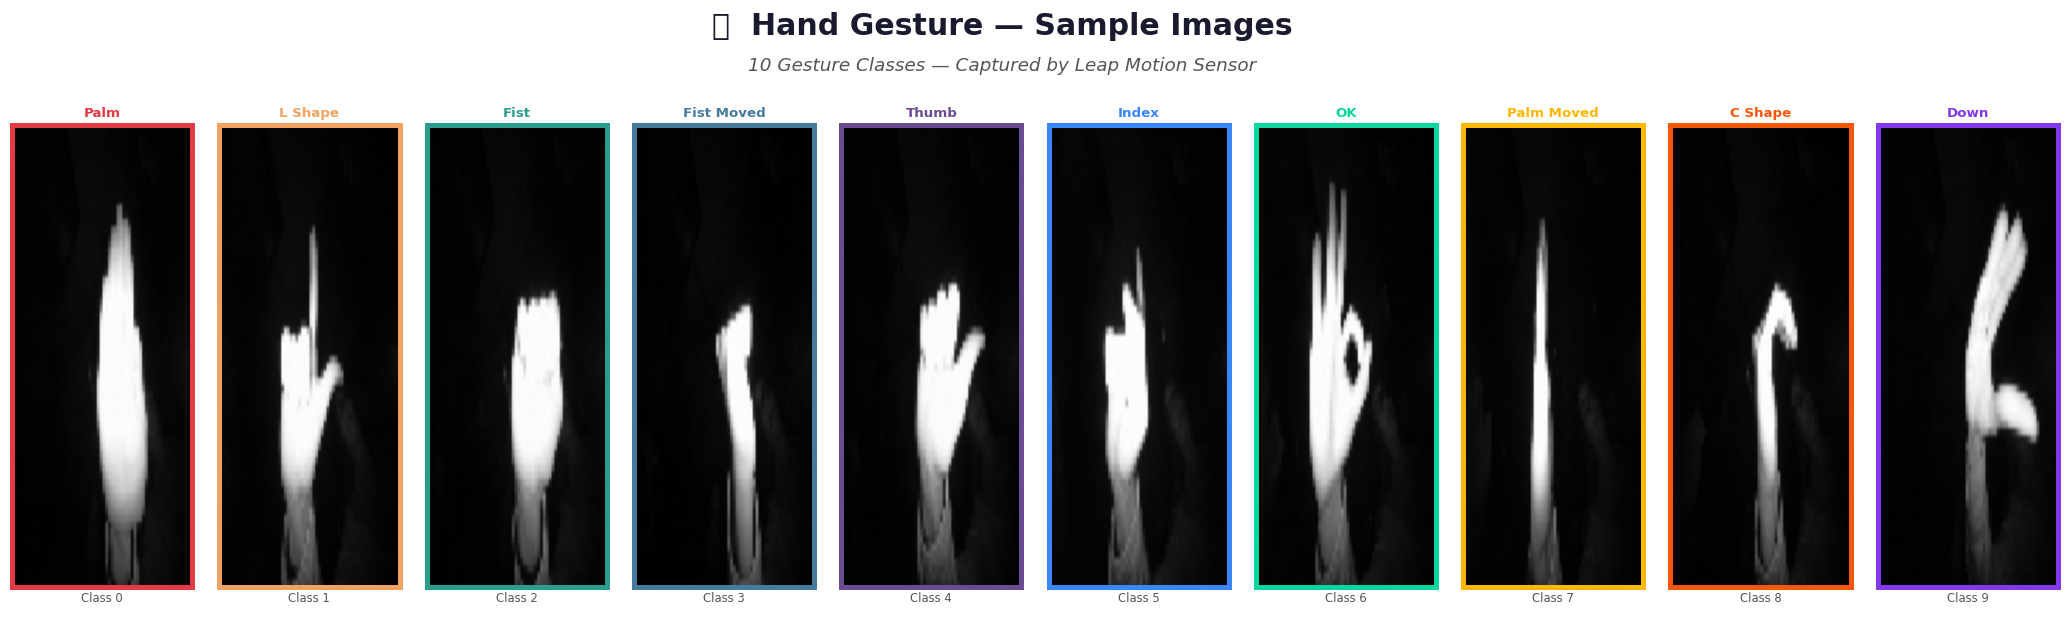

In [6]:
fig = plt.figure(figsize=(22, 5))
fig.patch.set_facecolor('white')

fig.text(0.5, 1.03, '🖐️  Hand Gesture — Sample Images',
         ha='center', fontsize=18, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97, '10 Gesture Classes — Captured by Leap Motion Sensor',
         ha='center', fontsize=11, color='#555555', style='italic')

colors_list = ['#e63946','#f4a261','#2a9d8f','#457b9d',
               '#6a4c93','#3a86ff','#06d6a0','#ffb703',
               '#fb5607','#8338ec']

for class_id in range(len(gesture_labels)):
    idx  = np.where(y == class_id)[0][0]
    img  = X[idx].reshape(IMG_SIZE, IMG_SIZE)
    name = GESTURE_NAMES.get(gesture_labels[class_id],
                              gesture_labels[class_id])
    ax   = fig.add_subplot(1, 10, class_id + 1)
    ax.imshow(img, cmap='gray', aspect='auto')
    ax.set_title(f'{name}', fontsize=8,
                 fontweight='bold',
                 color=colors_list[class_id], pad=5)
    ax.set_xlabel(f'Class {class_id}', fontsize=7,
                  color='#555555', labelpad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(colors_list[class_id])
        s.set_linewidth(3)
        s.set_visible(True)

plt.subplots_adjust(wspace=0.15)
plt.show()

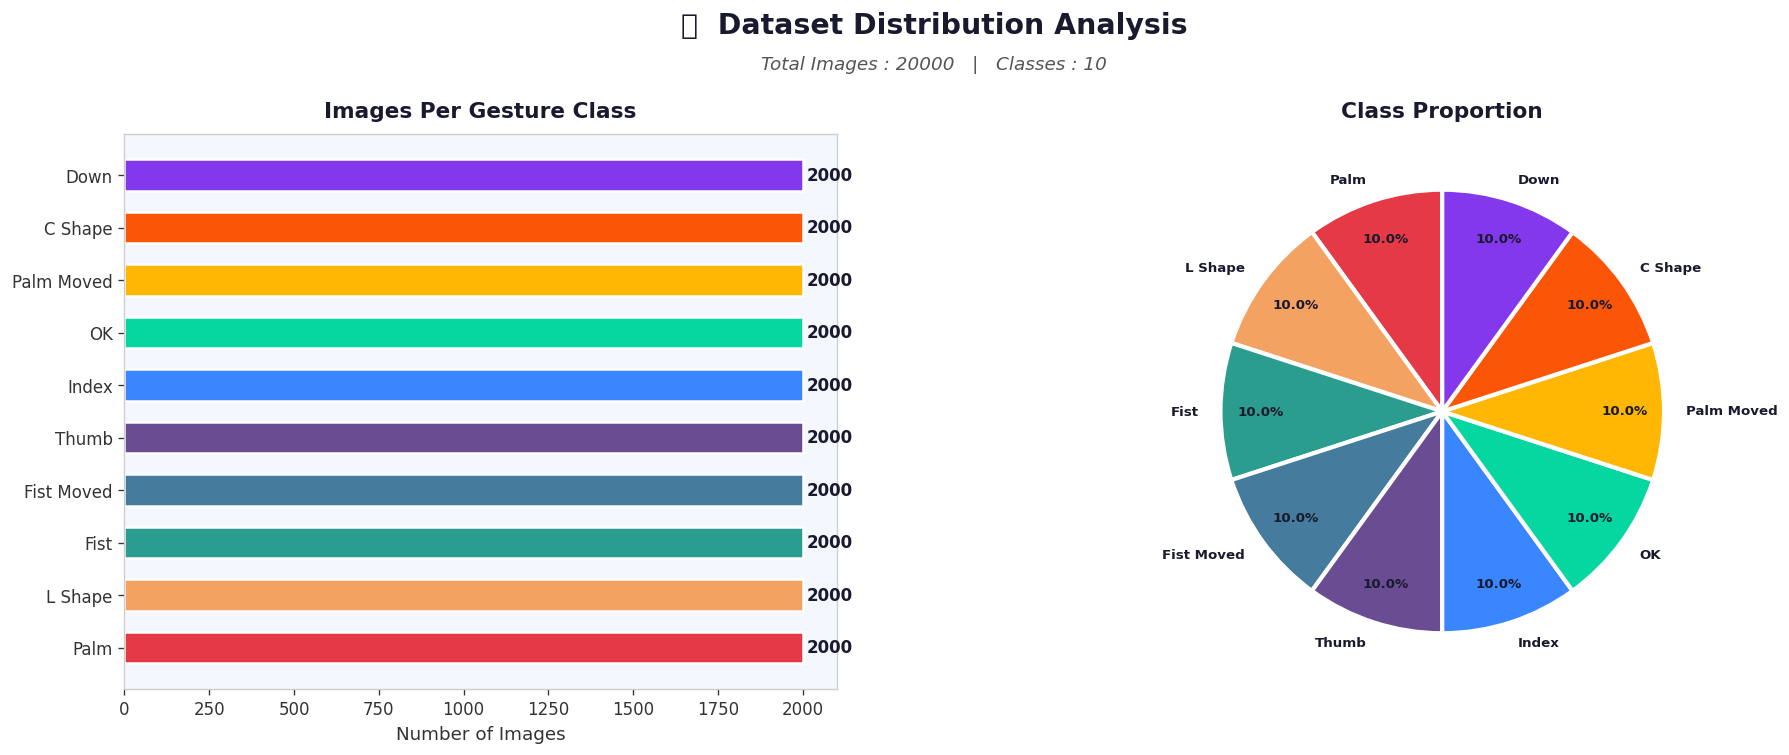

In [7]:
unique, counts = np.unique(y, return_counts=True)
names = [GESTURE_NAMES.get(gesture_labels[i], gesture_labels[i])
         for i in unique]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '📊  Dataset Distribution Analysis',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97, f'Total Images : {len(X)}   |   Classes : {len(unique)}',
         ha='center', fontsize=11, color='#555555', style='italic')

axes[0].set_facecolor('#f5f7ff')
bars = axes[0].barh(names, counts, color=colors_list,
                    edgecolor='white', linewidth=1.5, height=0.6)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold',
                 fontsize=10, color='#1a1a2e')
axes[0].set_title('Images Per Gesture Class',
                  fontweight='bold', color='#1a1a2e', fontsize=13, pad=10)
axes[0].set_xlabel('Number of Images', color='#333333', fontsize=11)
axes[0].tick_params(colors='#333333')
for spine in axes[0].spines.values():
    spine.set_color('#cccccc')

axes[1].set_facecolor('#f5f7ff')
wedges, texts, pcts = axes[1].pie(
    counts, labels=names,
    autopct='%1.1f%%',
    colors=colors_list,
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 8, 'fontweight': 'bold', 'color': '#1a1a2e'}
)
for pct in pcts:
    pct.set_fontsize(8)
axes[1].set_title('Class Proportion',
                  fontweight='bold', color='#1a1a2e', fontsize=13, pad=10)

plt.subplots_adjust(wspace=0.35)
plt.show()

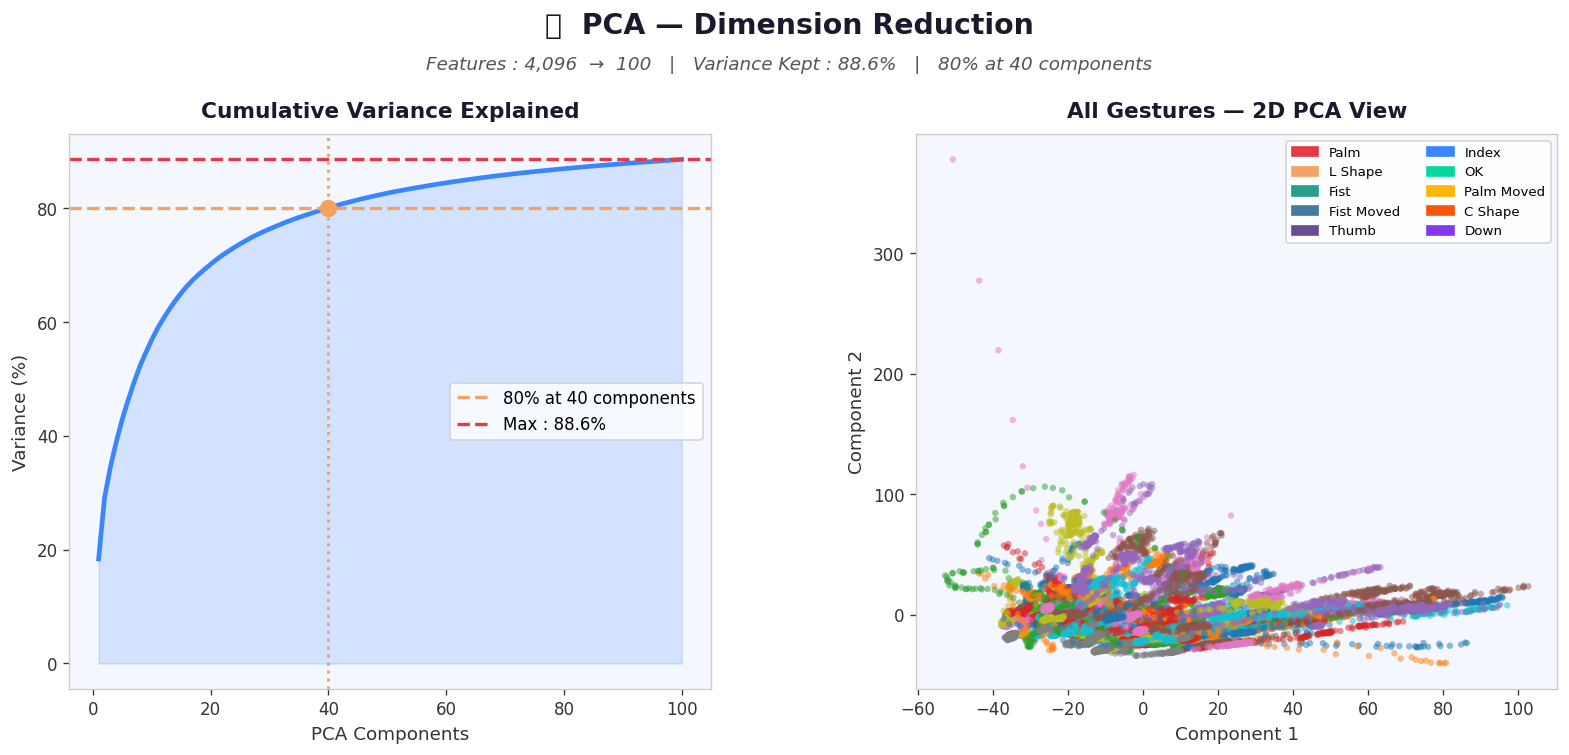

✅ Original Features : 4,096
✅ After PCA         : 100
📊 Variance Retained : 88.6%


In [8]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca   = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_) * 100
comp_80   = next(i for i, v in enumerate(explained) if v >= 80) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '🔬  PCA — Dimension Reduction',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97,
         f'Features : {X.shape[1]:,}  →  100   |   Variance Kept : {explained[-1]:.1f}%   |   80% at {comp_80} components',
         ha='center', fontsize=11, color='#555555', style='italic')

axes[0].set_facecolor('#f5f7ff')
axes[0].plot(range(1, 101), explained,
             color='#3a86ff', linewidth=2.8)
axes[0].fill_between(range(1, 101), explained,
                     alpha=0.18, color='#3a86ff')
axes[0].axhline(y=80, color='#f4a261', linestyle='--',
                linewidth=2, label=f'80% at {comp_80} components')
axes[0].axhline(y=explained[-1], color='#e63946', linestyle='--',
                linewidth=2, label=f'Max : {explained[-1]:.1f}%')
axes[0].axvline(x=comp_80, color='#f4a261', linestyle=':', linewidth=1.8)
axes[0].scatter([comp_80], [80], color='#f4a261', s=90, zorder=5)
axes[0].set_title('Cumulative Variance Explained',
                  fontweight='bold', color='#1a1a2e', fontsize=13, pad=10)
axes[0].set_xlabel('PCA Components', color='#333333', fontsize=11)
axes[0].set_ylabel('Variance (%)',   color='#333333', fontsize=11)
axes[0].tick_params(colors='#333333')
axes[0].legend(facecolor='white', edgecolor='#cccccc', fontsize=10)
for spine in axes[0].spines.values():
    spine.set_color('#cccccc')

axes[1].set_facecolor('#f5f7ff')
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=y, cmap='tab10',
                          alpha=0.5, s=15, edgecolors='none')
axes[1].set_title('All Gestures — 2D PCA View',
                  fontweight='bold', color='#1a1a2e', fontsize=13, pad=10)
axes[1].set_xlabel('Component 1', color='#333333', fontsize=11)
axes[1].set_ylabel('Component 2', color='#333333', fontsize=11)
axes[1].tick_params(colors='#333333')
legend_handles = [mpatches.Patch(color=colors_list[i],
                  label=GESTURE_NAMES.get(gesture_labels[i], gesture_labels[i]))
                  for i in range(len(gesture_labels))]
axes[1].legend(handles=legend_handles, facecolor='white',
               edgecolor='#cccccc', fontsize=8,
               loc='upper right', ncol=2)
for spine in axes[1].spines.values():
    spine.set_color('#cccccc')

plt.subplots_adjust(wspace=0.32)
plt.show()

print(f"✅ Original Features : {X.shape[1]:,}")
print(f"✅ After PCA         : {X_pca.shape[1]}")
print(f"📊 Variance Retained : {explained[-1]:.1f}%")

In [14]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# To display original images, we need the original (non-PCA) data split identically
# We ensure the same random_state and stratify to keep the splits consistent.
_, X_test_orig, _, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✂️  Data Split Done!")
print(f"🏋️  Train (PCA) : {len(X_train_pca)} images")
print(f"🧪 Test (PCA)  : {len(X_test_pca)} images")
print(f"\n🤖 Training SVM — RBF Kernel...")
print(f"⏳ Please wait 1-2 minutes...")
print("—" * 40)

svm = SVC(kernel='rbf', C=10, gamma='scale',
          decision_function_shape='ovr', random_state=42)
svm.fit(X_train_pca, y_train)

print("—" * 40)
print("✅ SVM Trained Successfully!")

✂️  Data Split Done!
🏋️  Train (PCA) : 16000 images
🧪 Test (PCA)  : 4000 images

🤖 Training SVM — RBF Kernel...
⏳ Please wait 1-2 minutes...
————————————————————————————————————————
————————————————————————————————————————
✅ SVM Trained Successfully!


In [15]:
y_pred = svm.predict(X_test_pca)
acc    = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

print("═" * 48)
print("📊   MODEL PERFORMANCE RESULTS")
print("═" * 48)
print(f"  ✅ Overall Accuracy : {acc*100:.2f}%")
print("—" * 48)
print(f"  {'Gesture':<16} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("—" * 48)
for i, g in enumerate(gesture_labels):
    name = GESTURE_NAMES.get(g, g)
    r    = report.get(str(i), {})
    print(f"  {name:<16} {r.get('precision',0)*100:>9.1f}% "
          f"{r.get('recall',0)*100:>9.1f}% "
          f"{r.get('f1-score',0)*100:>9.1f}%")
print("═" * 48)
bar_fill = int(acc * 30)
print(f"\n  Accuracy : [{'█'*bar_fill}{'░'*(30-bar_fill)}] {acc*100:.1f}%")

════════════════════════════════════════════════
📊   MODEL PERFORMANCE RESULTS
════════════════════════════════════════════════
  ✅ Overall Accuracy : 99.95%
————————————————————————————————————————————————
  Gesture           Precision     Recall         F1
————————————————————————————————————————————————
  Palm                  99.8%      99.8%      99.8%
  L Shape               99.8%     100.0%      99.9%
  Fist                 100.0%     100.0%     100.0%
  Fist Moved           100.0%     100.0%     100.0%
  Thumb                100.0%     100.0%     100.0%
  Index                100.0%     100.0%     100.0%
  OK                   100.0%      99.8%      99.9%
  Palm Moved           100.0%     100.0%     100.0%
  C Shape              100.0%     100.0%     100.0%
  Down                 100.0%     100.0%     100.0%
════════════════════════════════════════════════

  Accuracy : [█████████████████████████████░] 100.0%


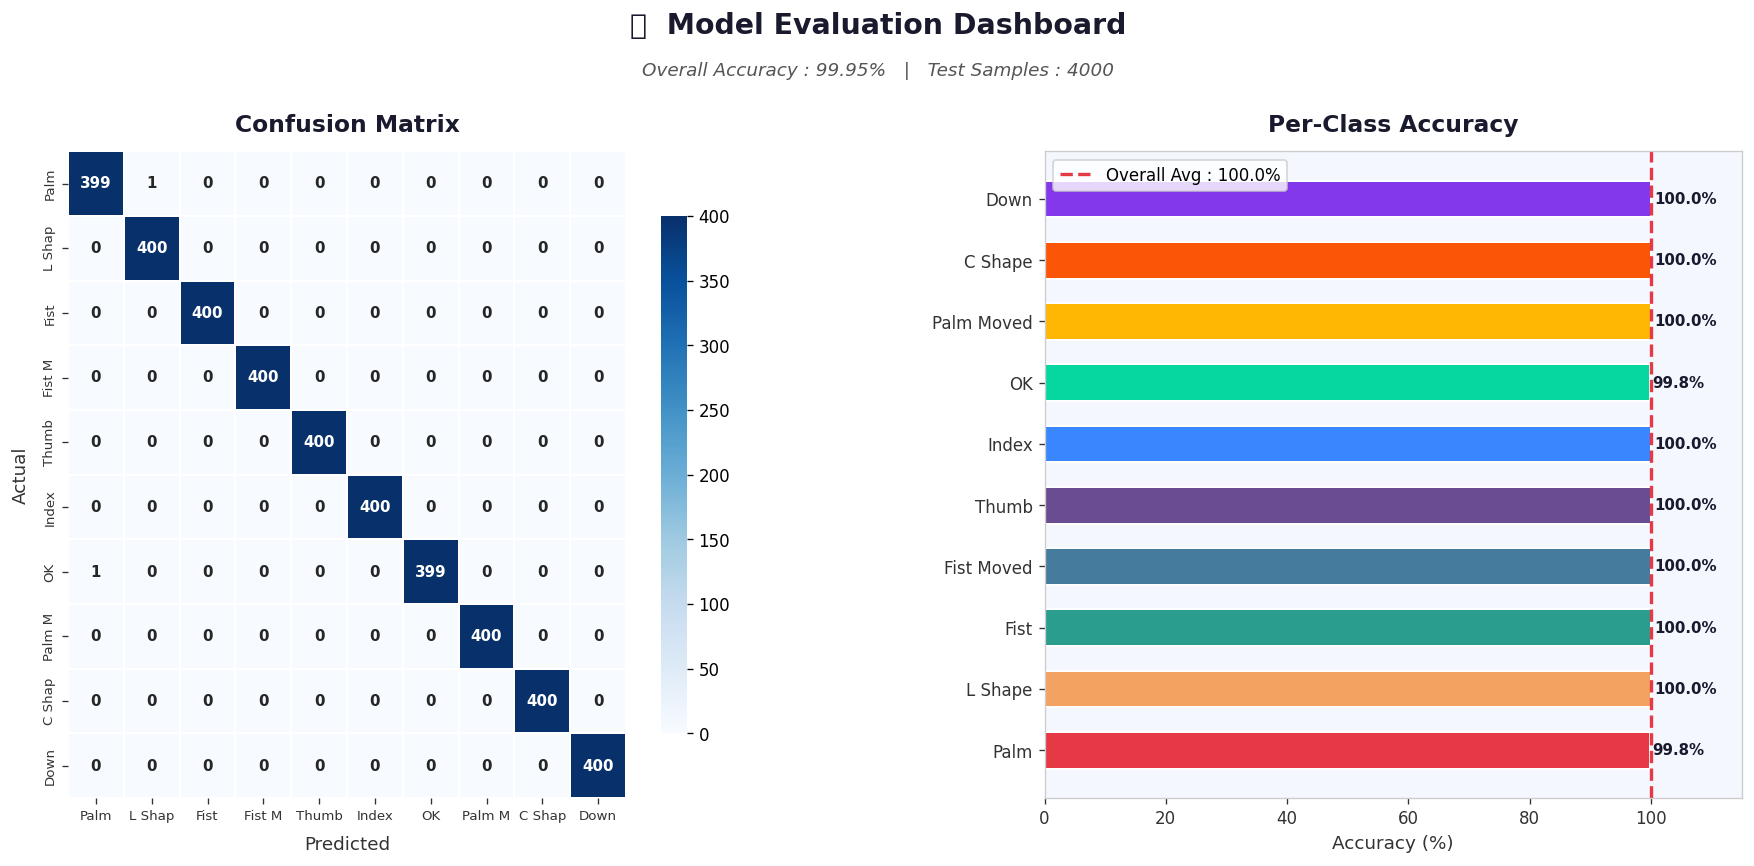

In [11]:
cm = confusion_matrix(y_test, y_pred)
short_names = [GESTURE_NAMES.get(g, g)[:6] for g in gesture_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '📊  Model Evaluation Dashboard',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97,
         f'Overall Accuracy : {acc*100:.2f}%   |   Test Samples : {len(y_test)}',
         ha='center', fontsize=11, color='#555555', style='italic')

axes[0].set_facecolor('#f5f7ff')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names,
            linewidths=1, linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix',
                  fontweight='bold', color='#1a1a2e', fontsize=14, pad=12)
axes[0].set_xlabel('Predicted', color='#333333', fontsize=11, labelpad=8)
axes[0].set_ylabel('Actual',    color='#333333', fontsize=11, labelpad=8)
axes[0].tick_params(colors='#333333', labelsize=8)

per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
full_names    = [GESTURE_NAMES.get(g, g) for g in gesture_labels]

axes[1].set_facecolor('#f5f7ff')
bars = axes[1].barh(full_names, per_class_acc,
                    color=colors_list, edgecolor='white',
                    linewidth=1.2, height=0.6)
axes[1].axvline(x=acc*100, color='#e63946', linestyle='--',
                linewidth=2, label=f'Overall Avg : {acc*100:.1f}%')
for bar, val in zip(bars, per_class_acc):
    axes[1].text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center',
                 fontweight='bold', fontsize=9, color='#1a1a2e')
axes[1].set_title('Per-Class Accuracy',
                  fontweight='bold', color='#1a1a2e', fontsize=14, pad=12)
axes[1].set_xlabel('Accuracy (%)', color='#333333', fontsize=11)
axes[1].set_xlim(0, 115)
axes[1].tick_params(colors='#333333', labelsize=10)
axes[1].legend(facecolor='white', edgecolor='#cccccc', fontsize=10)
for spine in axes[1].spines.values():
    spine.set_color('#cccccc')

plt.subplots_adjust(wspace=0.4)
plt.show()

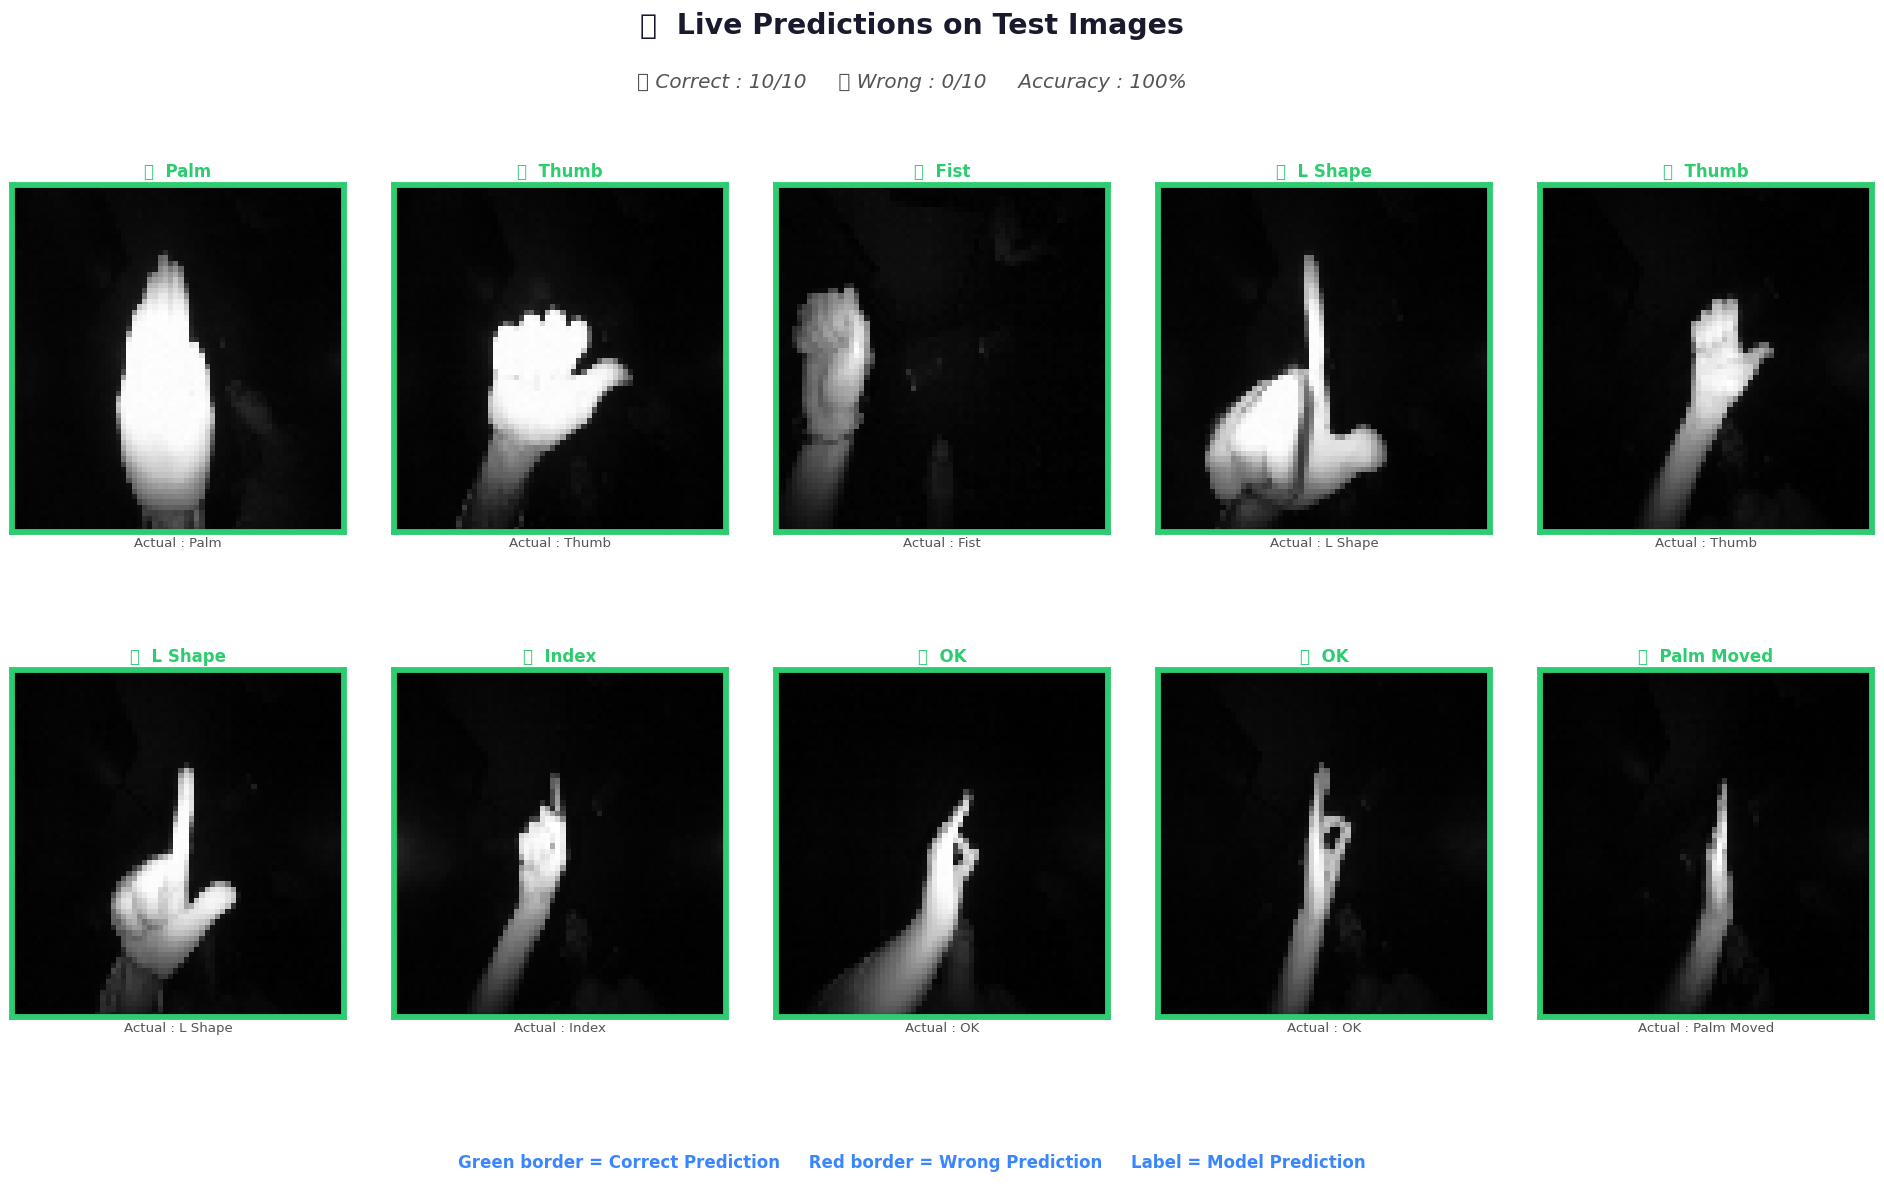

In [16]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_pca), 10, replace=False)

right = sum(y_pred[i] == y_test[i] for i in sample_idx)
wrong = 10 - right

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '🔍  Live Predictions on Test Images',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97,
         f'✅ Correct : {right}/10     ❌ Wrong : {wrong}/10     Accuracy : {right/10*100:.0f}%',
         ha='center', fontsize=12, color='#555555', style='italic')

for i, idx in enumerate(sample_idx):
    ax           = axes[i // 5][i % 5]
    img          = X_test_orig[idx].reshape(IMG_SIZE, IMG_SIZE) # Use X_test_orig for display
    pred         = y_pred[idx]
    actual       = y_test[idx]
    correct      = pred == actual
    pred_name    = GESTURE_NAMES.get(gesture_labels[pred],   gesture_labels[pred])
    actual_name  = GESTURE_NAMES.get(gesture_labels[actual], gesture_labels[actual])
    mark         = '✅' if correct else '❌'
    color        = '#2ecc71' if correct else '#e63946'
    bg           = '#f0fff4' if correct else '#fff0f0'

    ax.set_facecolor(bg)
    ax.imshow(img, cmap='gray', aspect='auto')
    ax.set_title(f'{mark}  {pred_name}',
                 fontsize=10, fontweight='bold', color=color, pad=5)
    ax.set_xlabel(f'Actual : {actual_name}',
                  fontsize=8, color='#555555', labelpad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(color)
        s.set_linewidth(3.5)
        s.set_visible(True)

fig.text(0.5, -0.03,
         'Green border = Correct Prediction     Red border = Wrong Prediction     Label = Model Prediction',
         ha='center', fontsize=10, color='#3a86ff', fontweight='bold')

plt.subplots_adjust(wspace=0.15, hspace=0.4)
plt.show()

In [17]:
W = 50

top = "╔" + "═" * W + "╗"
mid = "╠" + "═" * W + "╣"
bot = "╚" + "═" * W + "╝"

def section(title):
    pad_l = (W - len(title)) // 2
    pad_r =  W - len(title) - pad_l
    return f"║{' ' * pad_l}{title}{' ' * pad_r}║"

def row(label, value):
    content = f"  {label:<22} :  {value}"
    pad     = W - len(content)
    return f"║{content}{' ' * pad}║"

bar_fill = int(acc * 28)
bar_str  = "█" * bar_fill + "░" * (28 - bar_fill)
bar_line = f"  Accuracy Bar  : [{bar_str}]  {acc*100:.1f}%"
bar_pad  = W - len(bar_line)

print()
print(top)
print(section("HAND GESTURE RECOGNITION -- FINAL REPORT"))
print(mid)
print(section("---  Configuration  ---"))
print(mid)
print(row("Dataset",        "LeapGestRecog (Kaggle)"))
print(row("Total Images",   f"{len(X)}"))
print(row("Image Size",     f"{IMG_SIZE}x{IMG_SIZE} grayscale"))
print(row("Gesture Classes","10"))
print(row("PCA Components", "100"))
print(row("Algorithm",      "SVM  RBF Kernel"))
print(row("Train / Test",   "80%  /  20%"))
print(mid)
print(section("---  Performance Results  ---"))
print(mid)
print(row("Final Accuracy",  f"{acc*100:.2f}%"))
print(row("Test Samples",    f"{len(y_test)}"))
for i, g in enumerate(gesture_labels):
    name = GESTURE_NAMES.get(g, g)
    r    = report.get(str(i), {})
    print(row(f"{name} F1", f"{r.get('f1-score',0)*100:.1f}%"))
print(mid)
print(f"║{bar_line}{' ' * bar_pad}║")
print(mid)
print(section("TASK 04  --  COMPLETED SUCCESSFULLY"))
print(bot)


╔══════════════════════════════════════════════════╗
║     HAND GESTURE RECOGNITION -- FINAL REPORT     ║
╠══════════════════════════════════════════════════╣
║             ---  Configuration  ---              ║
╠══════════════════════════════════════════════════╣
║  Dataset                :  LeapGestRecog (Kaggle)║
║  Total Images           :  20000                 ║
║  Image Size             :  64x64 grayscale       ║
║  Gesture Classes        :  10                    ║
║  PCA Components         :  100                   ║
║  Algorithm              :  SVM  RBF Kernel       ║
║  Train / Test           :  80%  /  20%           ║
╠══════════════════════════════════════════════════╣
║          ---  Performance Results  ---           ║
╠══════════════════════════════════════════════════╣
║  Final Accuracy         :  99.95%                ║
║  Test Samples           :  4000                  ║
║  Palm F1                :  99.8%                 ║
║  L Shape F1             :  99.9%           